In [51]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Define transform
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 test set
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170498071/170498071 [00:14<00:00, 11622903.82it/s]


Extracting ./data\cifar-10-python.tar.gz to ./data


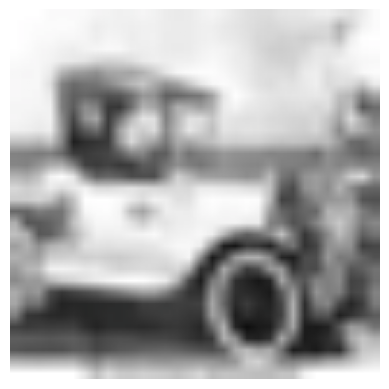

Label: automobile


In [32]:
# Undo normalization for plotting
def imshow(img):
    
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Visual check
images, labels = next(iter(test_loader))

random_image = randint(0, len(images) - 1)
imshow(images[random_image])

print("Label:", test_dataset.classes[labels[[random_image]]])

In [35]:
# Load pre-trained ResNet-18
resnet18 = models.resnet18(pretrained=True)

# Remove final classification layer (fc)
# We’ll use everything up to the last FC layer
model = nn.Sequential(*list(resnet18.children())[:-1])  # Exclude the classifier

# Set to evaluation mode
model.eval()

# Send to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [36]:
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [38]:
# Make sure model and dataloader are ready
model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)

        # Pass through model to get features
        features = model(images)  # Output shape: [B, 512, 1, 1]
        features = features.squeeze()  # Remove [1,1] dimensions → [B, 512]

        if len(features.shape) == 1:
            features = features.unsqueeze(0)  # Handle batch size = 1

        all_embeddings.append(features.cpu())
        all_labels.append(labels)

# Stack into arrays
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()  # Shape: [10000, 512]
all_labels = torch.cat(all_labels, dim=0).numpy()  # Shape: [10000]

100%|██████████| 157/157 [00:16<00:00,  9.47it/s]


In [43]:
os.makedirs("embeddings", exist_ok=True)
np.save("embeddings/resnet18_cifar10_embeddings.npy", all_embeddings)
np.save("embeddings/resnet18_cifar10_labels.npy", all_labels)

In [46]:
print(np.load("embeddings/resnet18_cifar10_embeddings.npy").shape)
print(np.load("embeddings/resnet18_cifar10_labels.npy").shape)

(10000, 512)
(10000,)


In [48]:
embeddings = np.load("embeddings/resnet18_cifar10_embeddings.npy")
labels = np.load("embeddings/resnet18_cifar10_labels.npy")

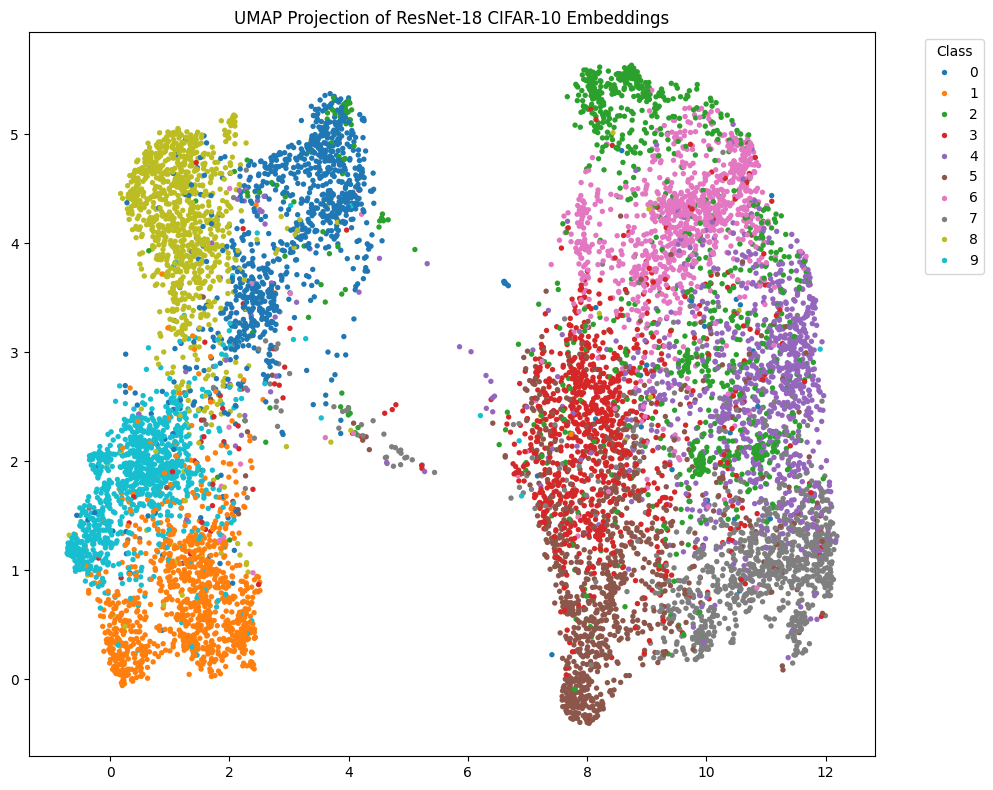

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)  # Shape: [10000, 2]

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("UMAP Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

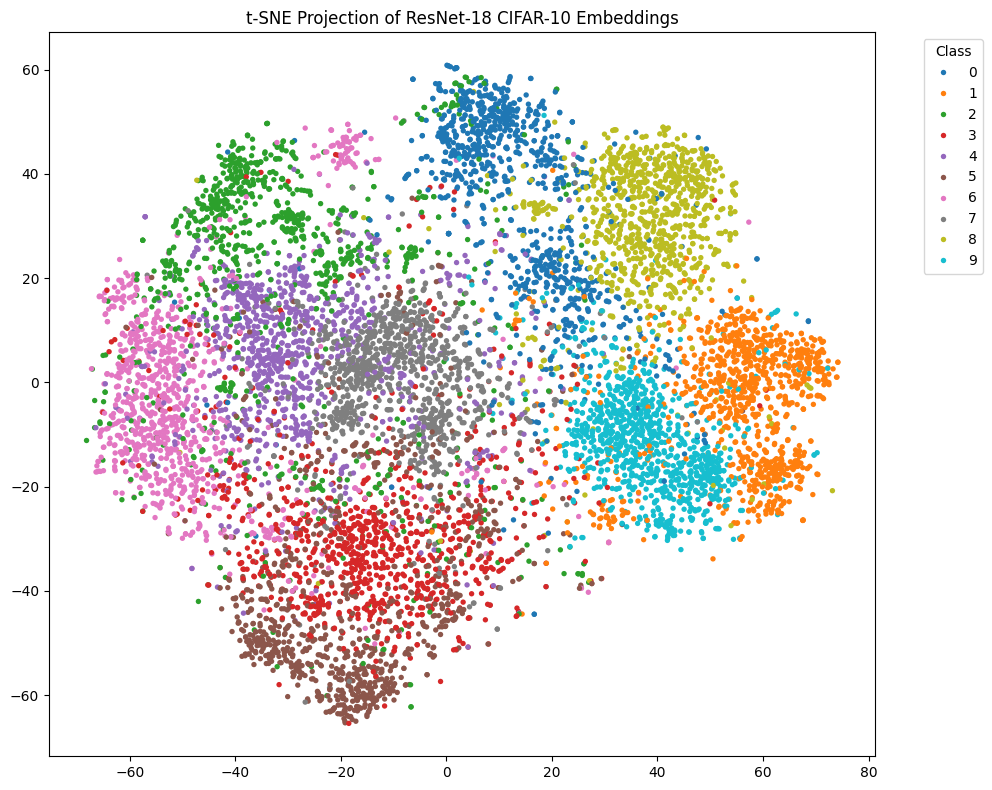

In [50]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("t-SNE Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [54]:
class_to_idx = {}
for idx, label in enumerate(labels):
    if label not in class_to_idx:
        class_to_idx[label] = idx
    if len(class_to_idx) == 10:
        break

top_k = 10
results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity to all embeddings
    similarities = cosine_similarity(query_embedding, embeddings)[0]  # shape: [10000]

    # Get top K most similar indices (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]

    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }


In [ ]:
def unnormalize(img_tensor):
    """
    Undo normalization to convert image tensor to [0,1] range for imshow
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor


def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    plt.figure(figsize=(12, 2))

    # Query image
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    # Neighbors
    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())

        # Get the actual label name from dataset.labels or dataset.targets
        nn_label_idx = dataset[idx][1]  # This is the label index
        nn_label_name = dataset.classes[nn_label_idx]

        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

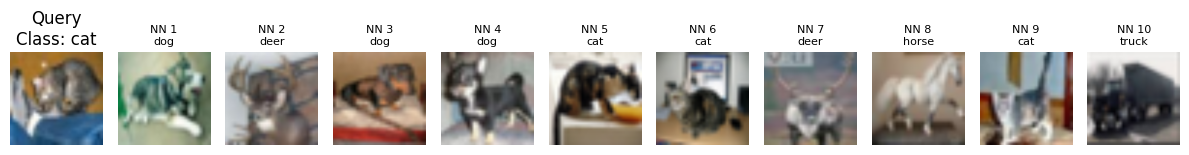

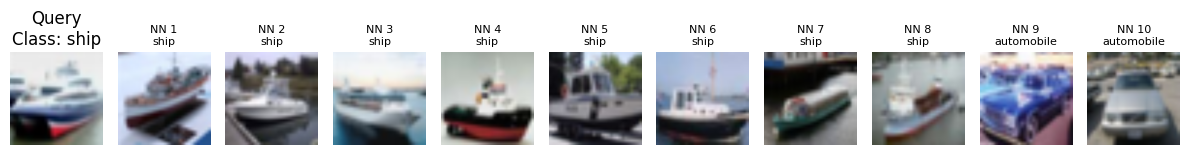

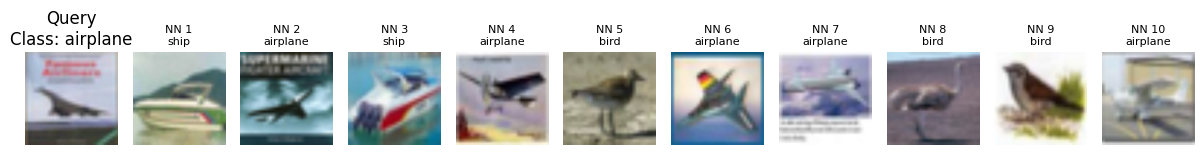

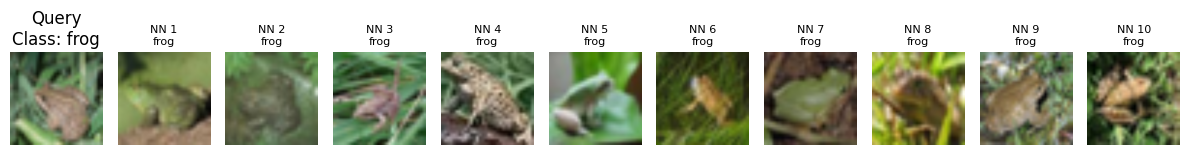

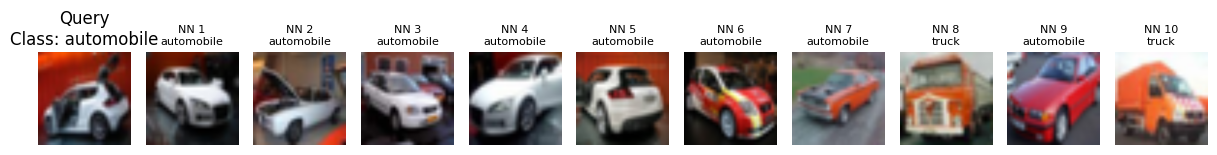

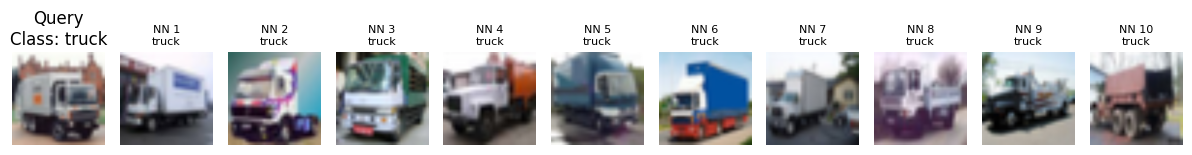

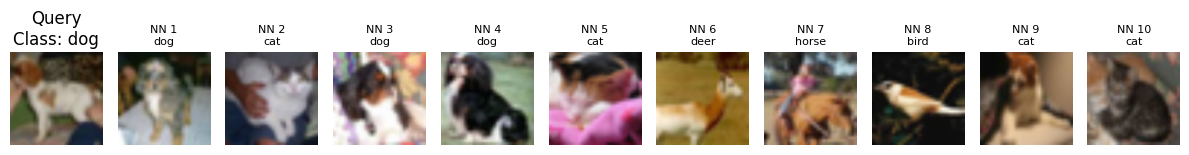

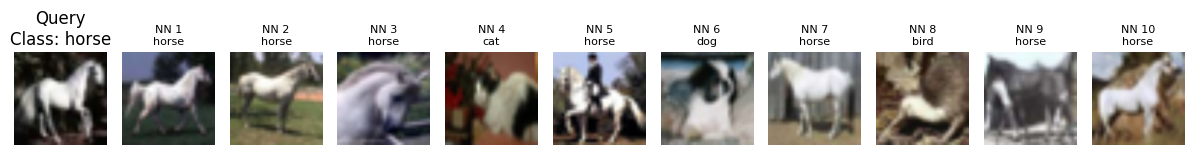

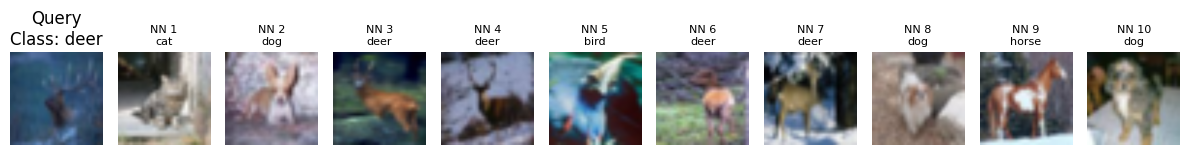

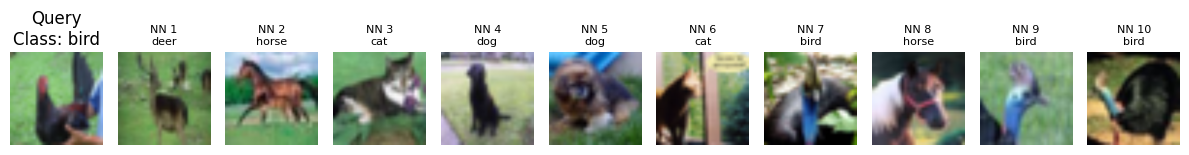

In [65]:
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.classes[class_label]
    )

In [ ]:

'''
feature_maps = {}

def get_hook(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

# Register hooks
layers_to_hook = {
    'conv1': model[0],      # conv1
    'layer1': model[4],     # resnet.layer1
    'layer2': model[5],     # resnet.layer2
    'layer3': model[6],     # resnet.layer3
    'layer4': model[7],     # resnet.layer4
}

for name, layer in layers_to_hook.items():
    layer.register_forward_hook(get_hook(name))
    
    
    
# Example: get one image
sample_idx = class_to_idx[0]  # 0 = 'airplane'
image, label = test_dataset[sample_idx]
image = image.unsqueeze(0).to(device)

# Clear old features
feature_maps.clear()

# Forward pass
with torch.no_grad():
    _ = model(image)
    
    
    
pooled_features = []

for layer in ['conv1','layer1','layer2','layer3','layer4']:
    fmap = feature_maps[layer]        # e.g. shape [1, C, H, W]
    pooled = torch.nn.functional.adaptive_avg_pool2d(fmap,(1,1))
    pooled = pooled.view(-1).cpu().numpy()           # shape [C]
    # zero-pad to length 512
    padded = np.zeros(512, dtype=pooled.dtype)
    padded[: pooled.shape[0]] = pooled
    pooled_features.append(padded)

# Now all are length-512 → can stack
pooled_features = np.stack(pooled_features, axis=0)  # shape [5, 512]


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
traj_2d = pca.fit_transform(pooled_features)  # → shape [5,2]

plt.plot(traj_2d[:,0], traj_2d[:,1], '-o')
for i, name in enumerate(['conv1','layer1','layer2','layer3','layer4']):
    plt.text(traj_2d[i,0]+0.1, traj_2d[i,1], name)
plt.show()
'''